# Comparing Results from 4 Regression Models: Timepoint T3 Models
### ElasticNet, Support Vector Regression, Partial Least Squares Regression, HistGradientBoosting Regressor

In [1]:
# Importing and loading results
import sys, os
sys.path.insert(0, '../src')
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
os.environ['PYTHONWARNINGS'] = 'ignore'
MODEL_DIR = os.path.abspath('../models/pain-reduction')

# Performance Metrics against Selected Features
### From Feature Frequency Lists

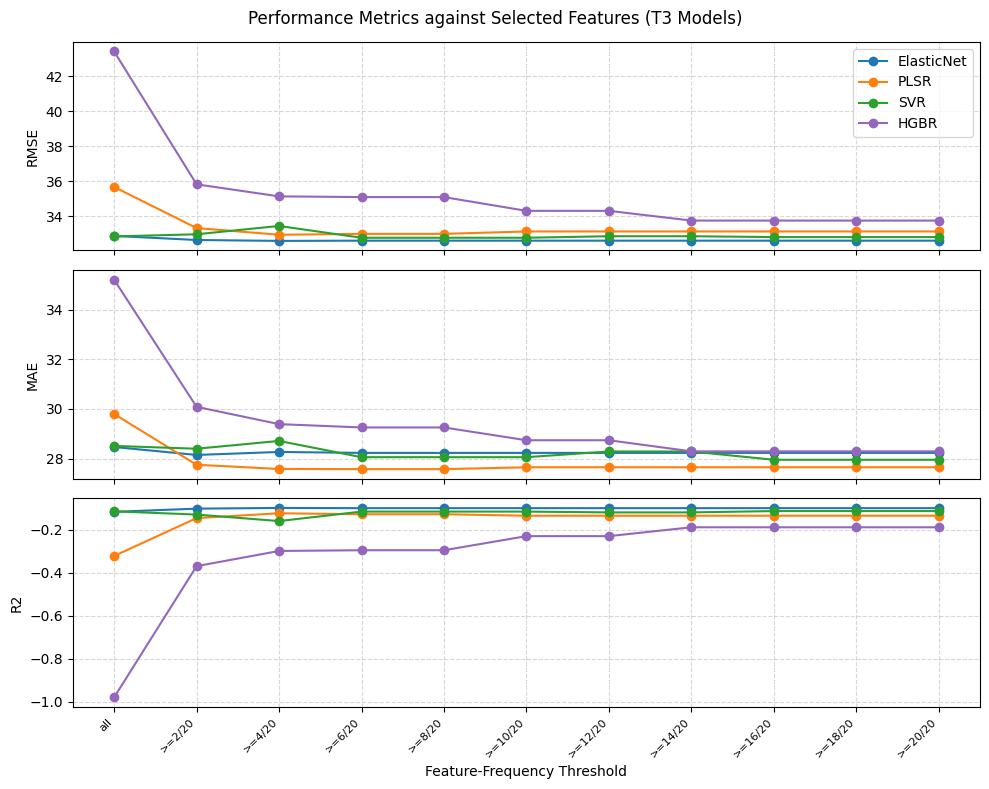

In [2]:
en_sweep = joblib.load(os.path.join(MODEL_DIR, 'en_sweep_df3.pkl'))
svr_sweep = joblib.load(os.path.join(MODEL_DIR, 'svr_sweep_df3.pkl'))
pls_sweep = joblib.load(os.path.join(MODEL_DIR, 'pls_sweep_df3.pkl'))
hgbr_sweep = joblib.load(os.path.join(MODEL_DIR, 'hgbr_sweep_df3.pkl'))
importlib.reload(model)
model.plot_sweep({'ElasticNet': en_sweep,
        'PLSR':   pls_sweep,
        'SVR':        svr_sweep,
        'HGBR':       hgbr_sweep}, title='Performance Metrics against Selected Features (T3 Models)')

## Summary: Mean Performance Metrics for All T3 Final Models

In [4]:
import pandas as pd
# Summary from Modeling-Notebooks
summary = pd.DataFrame({
    'Model':               ['ElasticNet',         'SVR',             'PLSR',          'HGBR'],
    'Cut-Off Feature sel.':['>=4/20',           '>=16/20',         '>=8/20',      '>=16/20'],
    'Mean RMSE':           ['32.577 ± 3.031', '32.795 ± 3.329', '32.980 ± 3.298', '33.653 ± 3.670'],
    'Mean MAE':            ['28.271 ± 3.294', '27.957 ± 3.484', ' 27.580 ± 3.411', '28.175 ± 3.385'],
    'Mean R2':             ['-0.099 ± 0.101','-0.113 ± 0.116', '-0.128 ± 0.139','-0.182 ± 0.216'],
})

summary.set_index('Model', inplace=True)
display(summary)

,Cut-Off Feature sel.,Mean RMSE,Mean MAE,Mean R2
Model,,,,
ElasticNet,>=4/20,32.577 ± 3.031,28.271 ± 3.294,-0.099 ± 0.101
SVR,>=16/20,32.795 ± 3.329,27.957 ± 3.484,-0.113 ± 0.116
PLSR,>=8/20,32.980 ± 3.298,27.580 ± 3.411,-0.128 ± 0.139
HGBR,>=16/20,33.653 ± 3.670,28.175 ± 3.385,-0.182 ± 0.216


## Significance testing
# Pairwise t-tests between Model Performance Metrics
Comparing performance metrics across 4 models, computing p-values and plotting heatmaps


  Pairwise Paired t-test (α=0.05)

  ElasticNet vs SVR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.4237      no
  MAE          0.1925      no
  R2           0.4275      no

  ElasticNet vs PLSR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.1508      no
  MAE          0.0158    *YES
  R2           0.1472      no

  ElasticNet vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.0566      no
  MAE          0.8557      no
  R2           0.0425    *YES

  SVR vs PLSR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.6059      no
  MAE          0.2303      no
  R2           0.5490      no

  SVR vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.0779      no
  MAE          0.6694      no
  R2           0.0545      no

  PLSR vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.1988      no
  MAE   

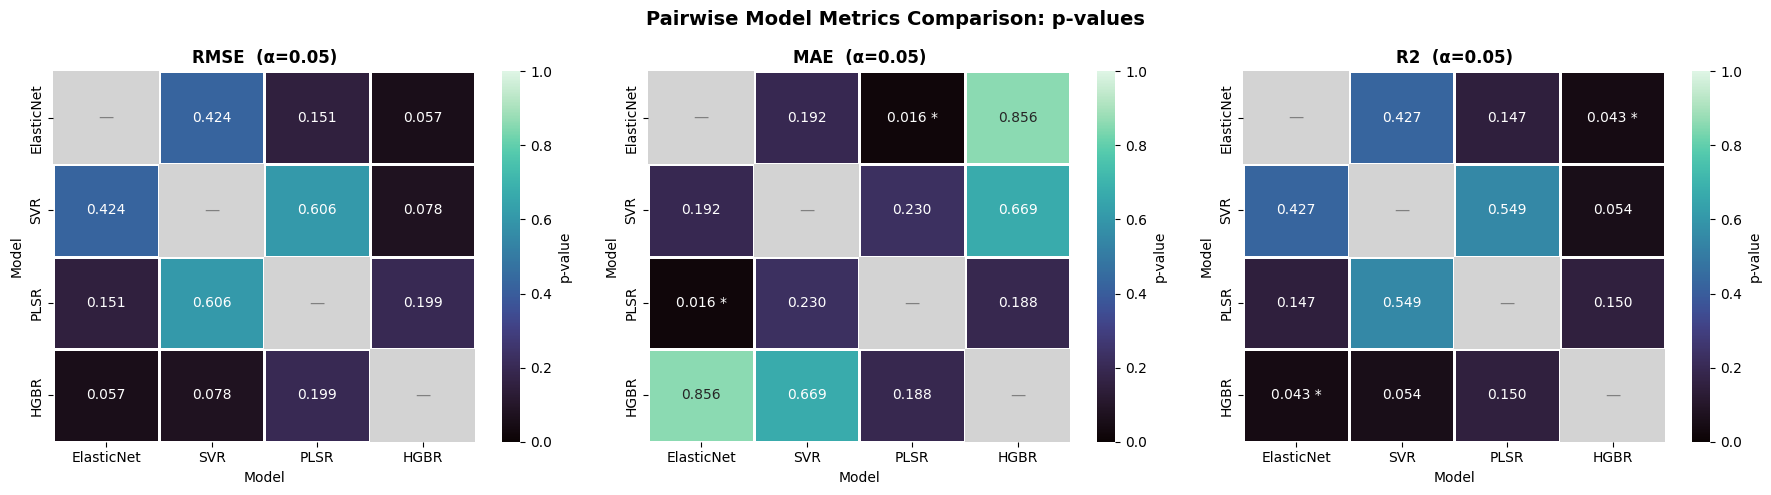

In [3]:
importlib.reload(model)
results_dict = {
    'ElasticNet': joblib.load(os.path.join(MODEL_DIR, 'en_results_df3.pkl')),
    'SVR':        joblib.load(os.path.join(MODEL_DIR, 'svr_results3.pkl')),
    'PLSR':        joblib.load(os.path.join(MODEL_DIR, 'pls_results3.pkl')),
    'HGBR':       joblib.load(os.path.join(MODEL_DIR, 'hgbr_results3.pkl')),
}

p_vals = model.pairwise_metric_comparison(results_dict, alpha=0.05)